# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mysqlsampledatabase (1).sql to mysqlsampledatabase (1).sql
Saving patient_demographics.csv to patient_demographics (1).csv
Saving clinical_data.csv to clinical_data (1).csv
Saving lifestyle_factors.csv to lifestyle_factors (1).csv


In [ ]:
# Load datasets
demographics = pd.read_csv("/content/patient_demographics.csv")
clinical = pd.read_csv("/content/clinical_data.csv")
lifestyle = pd.read_csv("/content/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [ ]:
#your code here

display(demographics.head())
display(demographics.info())
display(demographics.describe(include='all'))

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Country     8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB


None

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
count,8763,8763.000000,8763,8763.000000,8763,8763,8763
unique,8763,NaN,2,NaN,20,6,2
top,ZWN9666,NaN,Male,NaN,Germany,Asia,Northern Hemisphere
freq,1,NaN,6111,NaN,477,2543,5660
mean,NaN,53.707977,NaN,158263.181901,NaN,NaN,NaN
std,NaN,21.249509,NaN,80575.190806,NaN,NaN,NaN
min,NaN,18.000000,NaN,20062.000000,NaN,NaN,NaN
25%,NaN,35.000000,NaN,88310.000000,NaN,NaN,NaN
50%,NaN,54.000000,NaN,157866.000000,NaN,NaN,NaN
75%,NaN,72.000000,NaN,227749.000000,NaN,NaN,NaN


In [ ]:
#your code here

display(clinical.head())
display(clinical.info())
display(clinical.describe(include='all'))

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


None

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763,8763.000000,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
unique,8763,NaN,3915,NaN,NaN,NaN,NaN,NaN
top,ZWN9666,NaN,101/93,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,NaN,259.877211,NaN,75.021682,0.652288,0.492982,417.677051,28.891446
std,NaN,80.863276,NaN,20.550948,0.476271,0.499979,223.748137,6.319181
min,NaN,120.000000,NaN,40.000000,0.000000,0.000000,30.000000,18.002337
25%,NaN,192.000000,NaN,57.000000,0.000000,0.000000,225.500000,23.422985
50%,NaN,259.000000,NaN,75.000000,1.000000,0.000000,417.000000,28.768999
75%,NaN,330.000000,NaN,93.000000,1.000000,1.000000,612.000000,34.324594


In [ ]:
#your code here

display(lifestyle.head())
display(lifestyle.info())
display(lifestyle.describe(include='all'))

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   object 
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


None

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
count,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763,8763.000000,8763.000000
unique,8763,NaN,NaN,NaN,NaN,3,NaN,NaN
top,ZWN9666,NaN,NaN,NaN,NaN,Healthy,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,2960,NaN,NaN
mean,NaN,0.896839,0.501426,0.598083,10.014284,NaN,5.469702,0.358211
std,NaN,0.304186,0.500026,0.490313,5.783745,NaN,2.859622,0.479502
min,NaN,0.000000,0.000000,0.000000,0.002442,NaN,1.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,4.981579,NaN,3.000000,0.000000
50%,NaN,1.000000,1.000000,1.000000,10.069559,NaN,5.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,15.050018,NaN,8.000000,1.000000


# Docs:
1. Numerical values of blood pressure has been formatted as a string which needs to be split to get the integer data.
2. The categorical data needs to be encoded.
3. Unneeded and random data such as Patient ID need to be removed.

# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [ ]:
clinical['Blood Pressure'].head(10)

,Blood Pressure
0,158/88
1,165/93
2,174/99
3,163/100
4,91/88
5,172/86
6,102/73
7,131/68
8,144/105
9,160/70


In [ ]:
#your code here

# Split blood pressure
clinical[['High BP', 'Low BP']] = clinical['Blood Pressure'].str.split('/', expand=True)

In [ ]:
#your code here

# Convert the new columns to numeric type
clinical['High BP'] = pd.to_numeric(clinical['High BP'])
clinical['Low BP'] = pd.to_numeric(clinical['Low BP'])

In [ ]:
#your code here

# Display the head of the DataFrame with the new columns
display(clinical.head())

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,High BP,Low BP
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88


# Docs:
1. The blood pressure is stored as string so we cannot compute mean directly.
2. So we split the string at the '/' symbol to get the numeric values.

## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [ ]:
#your code here

print("Missing values in Demographics DataFrame:")
missing_demographics = demographics.isna().sum()
display(missing_demographics)

Missing values in Demographics DataFrame:


,0
Patient ID,0
Age,0
Sex,0
Income,0
Country,0
Continent,0
Hemisphere,0


In [ ]:
#your code here

print("Missing values in Clinical DataFrame:")
missing_clinical = clinical.isna().sum()
display(missing_clinical)

Missing values in Clinical DataFrame:


,0
Patient ID,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Triglycerides,0
BMI,0
High BP,0
Low BP,0


In [ ]:
#your code here

print("Missing values in Lifestyle DataFrame:")
missing_lifestyle = lifestyle.isnull().sum()
display(missing_lifestyle)

Missing values in Lifestyle DataFrame:


,0
Patient ID,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Diet,0
Stress Level,0
Heart Attack Risk,0


# Docs:
1. There are no missing values in the dataset.

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


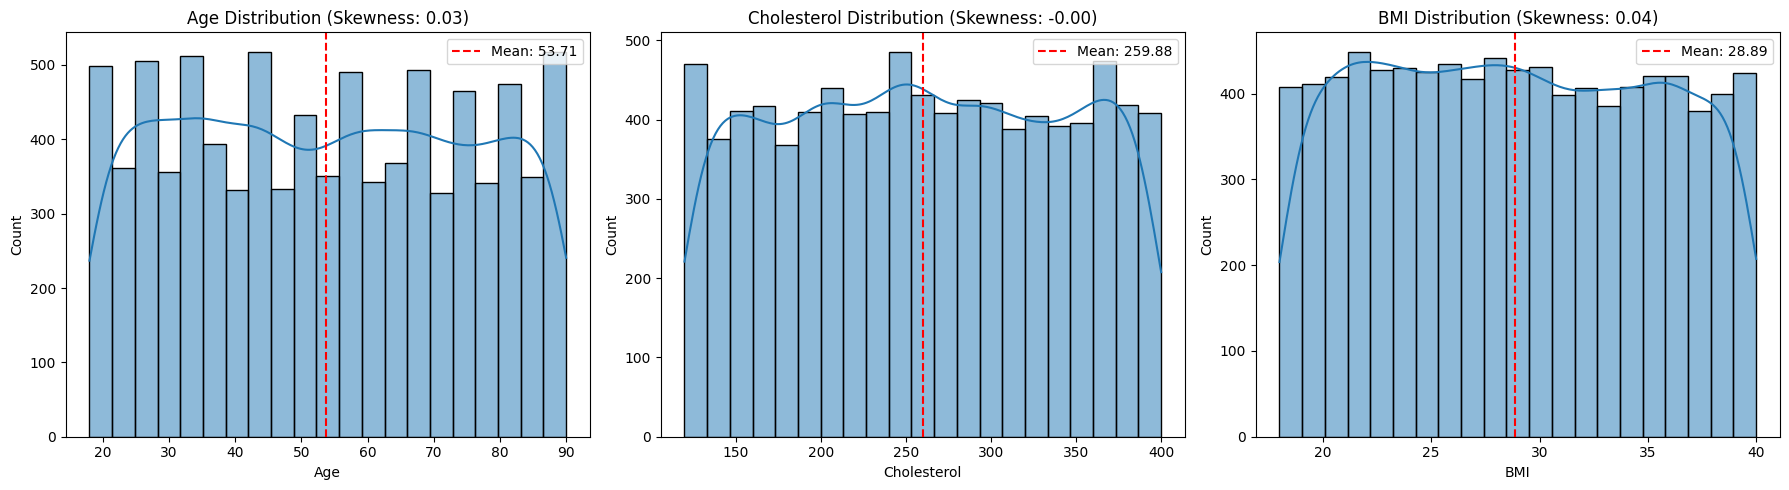

In [ ]:
plt.figure(figsize=(18, 5))

# Age Distribution
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.histplot(data=demographics, x='Age', kde=True)
plt.axvline(demographics['Age'].mean(), color='red', linestyle='--', label=f"Mean: {demographics['Age'].mean():.2f}")
age_skew = demographics['Age'].skew()
plt.title(f'Age Distribution (Skewness: {age_skew:.2f})')
plt.legend()

# Cholesterol Distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.histplot(data=clinical, x='Cholesterol', kde=True)
plt.axvline(clinical['Cholesterol'].mean(), color='red', linestyle='--', label=f"Mean: {clinical['Cholesterol'].mean():.2f}")
cholesterol_skew = clinical['Cholesterol'].skew()
plt.title(f'Cholesterol Distribution (Skewness: {cholesterol_skew:.2f})')
plt.legend()

# BMI Distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.histplot(data=clinical, x='BMI', kde=True)
plt.axvline(clinical['BMI'].mean(), color='red', linestyle='--', label=f"Mean: {clinical['BMI'].mean():.2f}")
bmi_skew = clinical['BMI'].skew()
plt.title(f'BMI Distribution (Skewness: {bmi_skew:.2f})')
plt.legend()

plt.tight_layout()
plt.show()

# Docs:
1. The required features: age, cholesterol and bmi seem to be normally distributed as per the plots.
2. The skewness values for all 3 are very low, so we do not need any transformations to them.

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

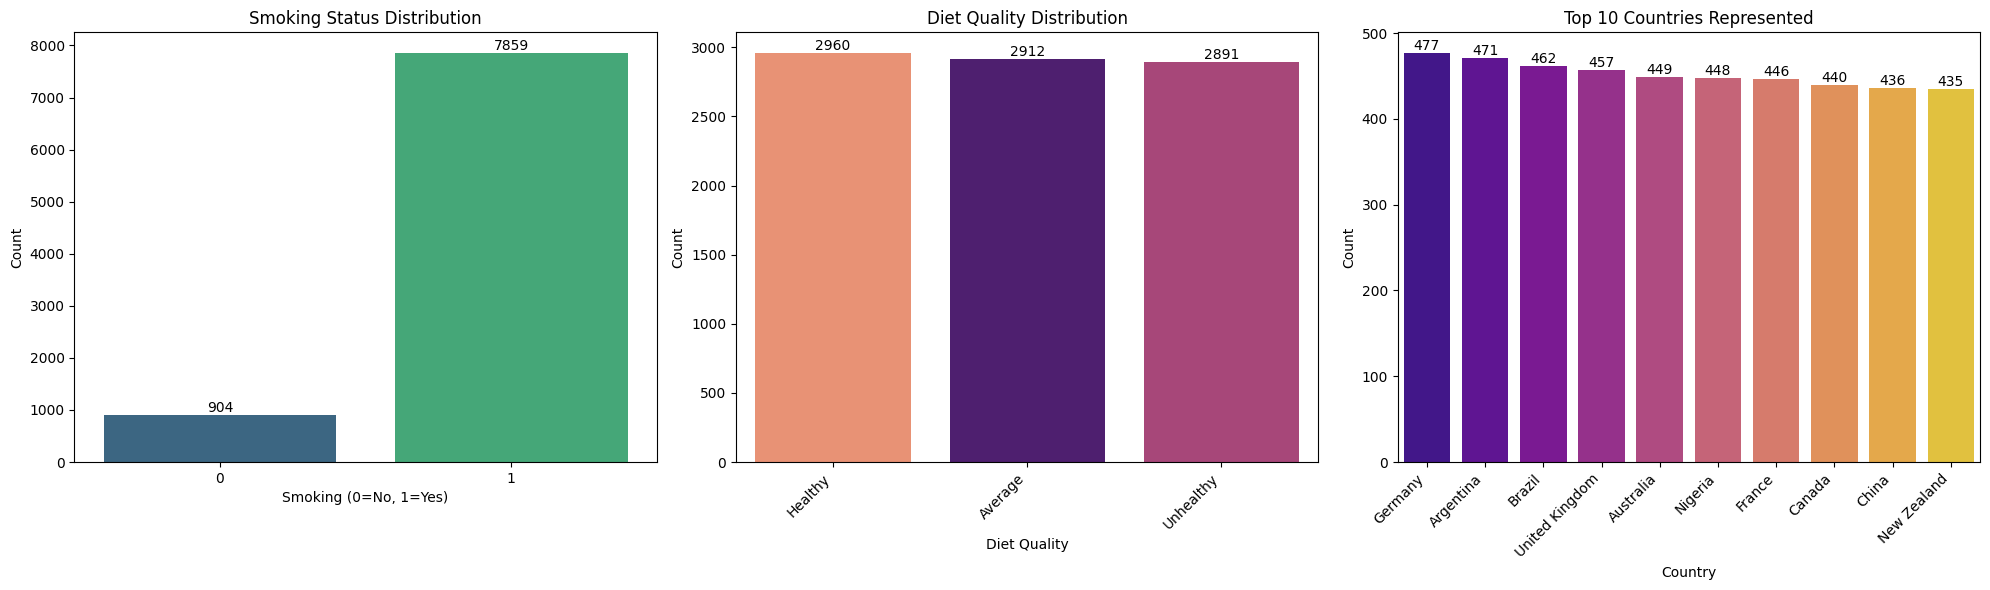

In [ ]:
plt.figure(figsize=(20, 6))

# Smoking Status Distribution
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
ax1 = sns.countplot(data=lifestyle, x='Smoking', palette='viridis', hue='Smoking', legend=False)
plt.title('Smoking Status Distribution')
plt.xlabel('Smoking (0=No, 1=Yes)')
plt.ylabel('Count')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Diet Quality Distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
ax2 = sns.countplot(data=lifestyle, x='Diet', order=lifestyle['Diet'].value_counts().index, palette='magma', hue='Diet', legend=False)
plt.title('Diet Quality Distribution')
plt.xlabel('Diet Quality')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Top 10 Countries Distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
top_10_countries = demographics['Country'].value_counts().head(10)
ax3 = sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='plasma', hue=top_10_countries.index, legend=False)
plt.title('Top 10 Countries Represented')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for p in ax3.patches:
    ax3.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Docs:
1. 7859 out of 8763 patients smoke.
2. The Diet categories are similar but Healthy Diet is slightly more common.
3. The most represented countries are Germany, Argentina, Brazil and so on as shown above.

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

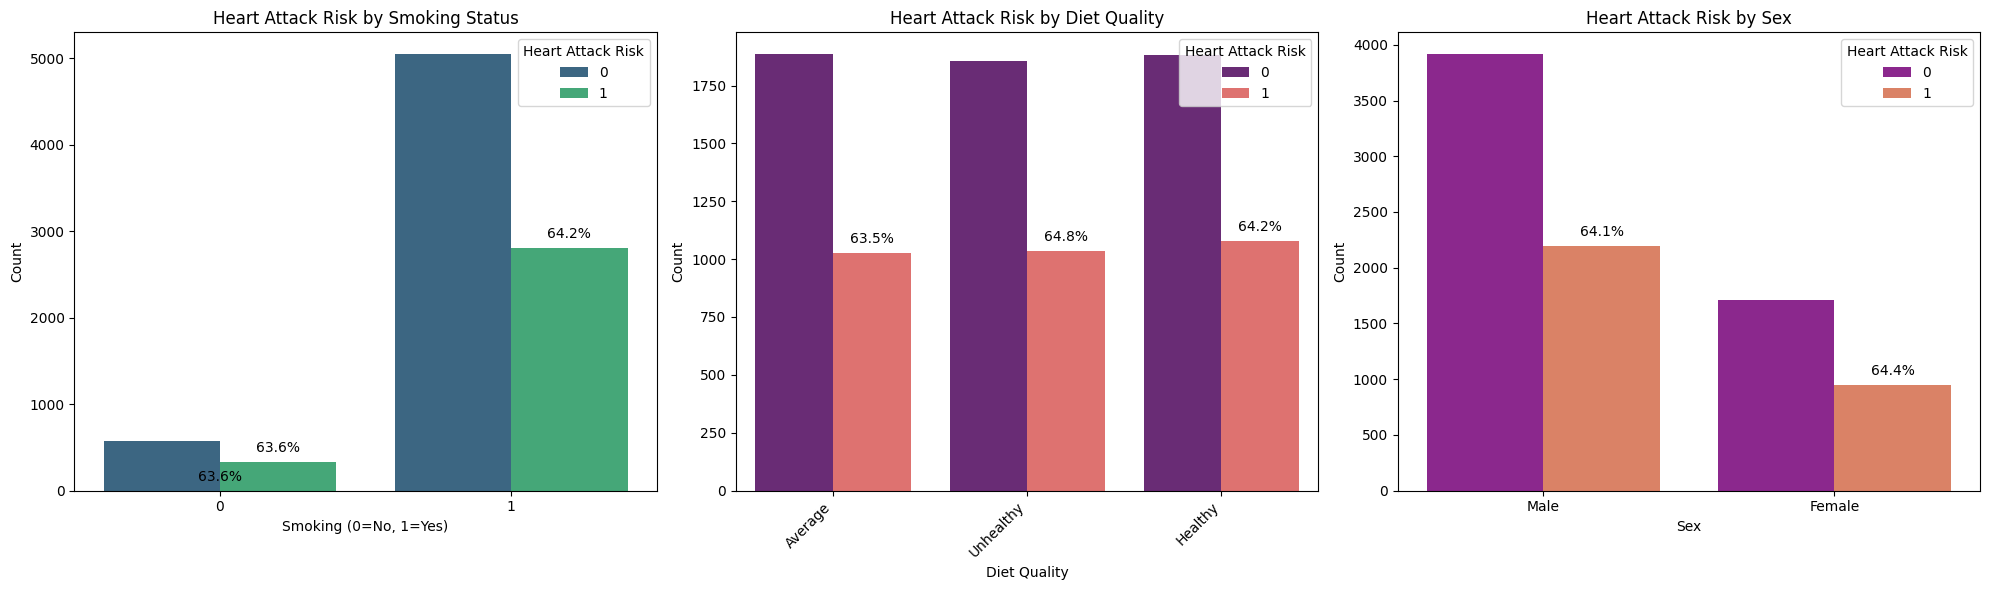

In [ ]:
merged_data = pd.merge(lifestyle, demographics[['Patient ID', 'Sex']], on='Patient ID', how='left')

plt.figure(figsize=(20, 6))

# Smoking vs Heart Attack Risk
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
ax1 = sns.countplot(data=merged_data, x='Smoking', hue='Heart Attack Risk', palette='viridis')
plt.title('Heart Attack Risk by Smoking Status')
plt.xlabel('Smoking (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk')

smoking_risk_props = merged_data.groupby('Smoking')['Heart Attack Risk'].mean()
for p in ax1.patches:
    height = p.get_height()
    x_val = p.get_x() + p.get_width() / 2
    # Determine which risk group (0 or 1) the bar belongs to
    if p.get_facecolor() == ax1.containers[0].get_children()[0].get_facecolor(): # Color of Heart Attack Risk 0
        # This bar represents Heart Attack Risk = 0
        risk_group = 0
    else: # Color of Heart Attack Risk 1
        # This bar represents Heart Attack Risk = 1
        risk_group = 1

    # Get the category value (0 or 1 for Smoking)
    category_val = int(x_val > (ax1.get_xlim()[1] - ax1.get_xlim()[0]) / 2)

    # Only annotate the 'Heart Attack Risk = 1' bars with proportion
    if risk_group == 1:
        prop = 100 - smoking_risk_props.get(category_val, 0) * 100
        ax1.annotate(f'{prop:.1f}%', (x_val, height), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# Diet vs Heart Attack Risk
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
ax2 = sns.countplot(data=merged_data, x='Diet', hue='Heart Attack Risk', palette='magma')
plt.title('Heart Attack Risk by Diet Quality')
plt.xlabel('Diet Quality')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Heart Attack Risk')

diet_risk_props = merged_data.groupby('Diet')['Heart Attack Risk'].mean()
diet_categories = merged_data['Diet'].value_counts().index.tolist() # Ensure consistent order

for i, p in enumerate(ax2.patches):
    height = p.get_height()
    x_val = p.get_x() + p.get_width() / 2

    # Determine which risk group (0 or 1) the bar belongs to
    if p.get_facecolor() == ax2.containers[0].get_children()[0].get_facecolor(): # Color of Heart Attack Risk 0
        risk_group = 0
    else: # Color of Heart Attack Risk 1
        risk_group = 1

    # Calculate the category index based on x position and then get the category name
    # The width of a group of bars (Risk 0 and Risk 1) is roughly 0.8
    # The number of categories is len(diet_categories)
    num_categories = len(diet_categories)
    cat_index = int(x_val / (ax2.get_xlim()[1] / num_categories))

    # More robust way to get category based on bar x position
    # x_ticks = ax2.get_xticks()
    # closest_tick_index = np.argmin(np.abs(x_ticks - (x_val + p.get_width()/2)))
    # category_name = diet_categories[closest_tick_index]

    # Simplified: map patches to categories by visual grouping. This assumes a fixed order.
    # There are two bars per category. First half for Risk 0, second half for Risk 1.
    if len(ax2.containers) > 1:
        # Assuming containers[0] is Risk 0 and containers[1] is Risk 1
        is_risk_1_bar = p in ax2.containers[1].get_children()
    else:
        is_risk_1_bar = False # Should not happen if hue is 'Heart Attack Risk'

    if is_risk_1_bar:
        # Find the category index. Bars for each category are grouped.
        # There are `num_categories` groups of 2 bars. Index `j` for category `j` starts at `j*2`.
        # The x-position of bar is roughly `category_index` - (width/2) or `category_index` + (width/2)
        # We need the actual category string
        # Loop through categories to find which bar it belongs to
        for k, cat_name in enumerate(diet_categories):
            # Check if this patch belongs to the current category 'cat_name'
            # This is tricky with sns.countplot, easier to just use the correct groupby.mean()

            # A simpler approach: iterate through the mean series directly
            pass # Annotation done outside this loop for diet and sex

# Annotate Diet plots after drawing all bars
for k, category_name in enumerate(diet_categories):
    prop = 100 - diet_risk_props.get(category_name, 0) * 100
    # Find the x-coordinate for the 'Heart Attack Risk = 1' bar for this category
    # This assumes a standard seaborn countplot layout
    for p in ax2.containers[1].get_children(): # Iterate through 'Heart Attack Risk = 1' bars
        if p.get_x() + p.get_width()/2 > k - 0.5 and p.get_x() + p.get_width()/2 < k + 0.5:
            ax2.annotate(f'{prop:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
            break


# Sex vs Heart Attack Risk
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
ax3 = sns.countplot(data=merged_data, x='Sex', hue='Heart Attack Risk', palette='plasma')
plt.title('Heart Attack Risk by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk')

sex_risk_props = merged_data.groupby('Sex')['Heart Attack Risk'].mean()
sex_categories = merged_data['Sex'].value_counts().index.tolist()

# Annotate Sex plots after drawing all bars
for k, category_name in enumerate(sex_categories):
    prop = 100 - sex_risk_props.get(category_name, 0) * 100
    for p in ax3.containers[1].get_children(): # Iterate through 'Heart Attack Risk = 1' bars
        if p.get_x() + p.get_width()/2 > k - 0.5 and p.get_x() + p.get_width()/2 < k + 0.5:
            ax3.annotate(f'{prop:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
            break

plt.tight_layout()
plt.show()

# Docs:
1. Smokers show slightly higher risk as seen the in the Heart Attack Risk percentage above.
2. The affect of diet is minimal.
3. The risk is similar in both genders.

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

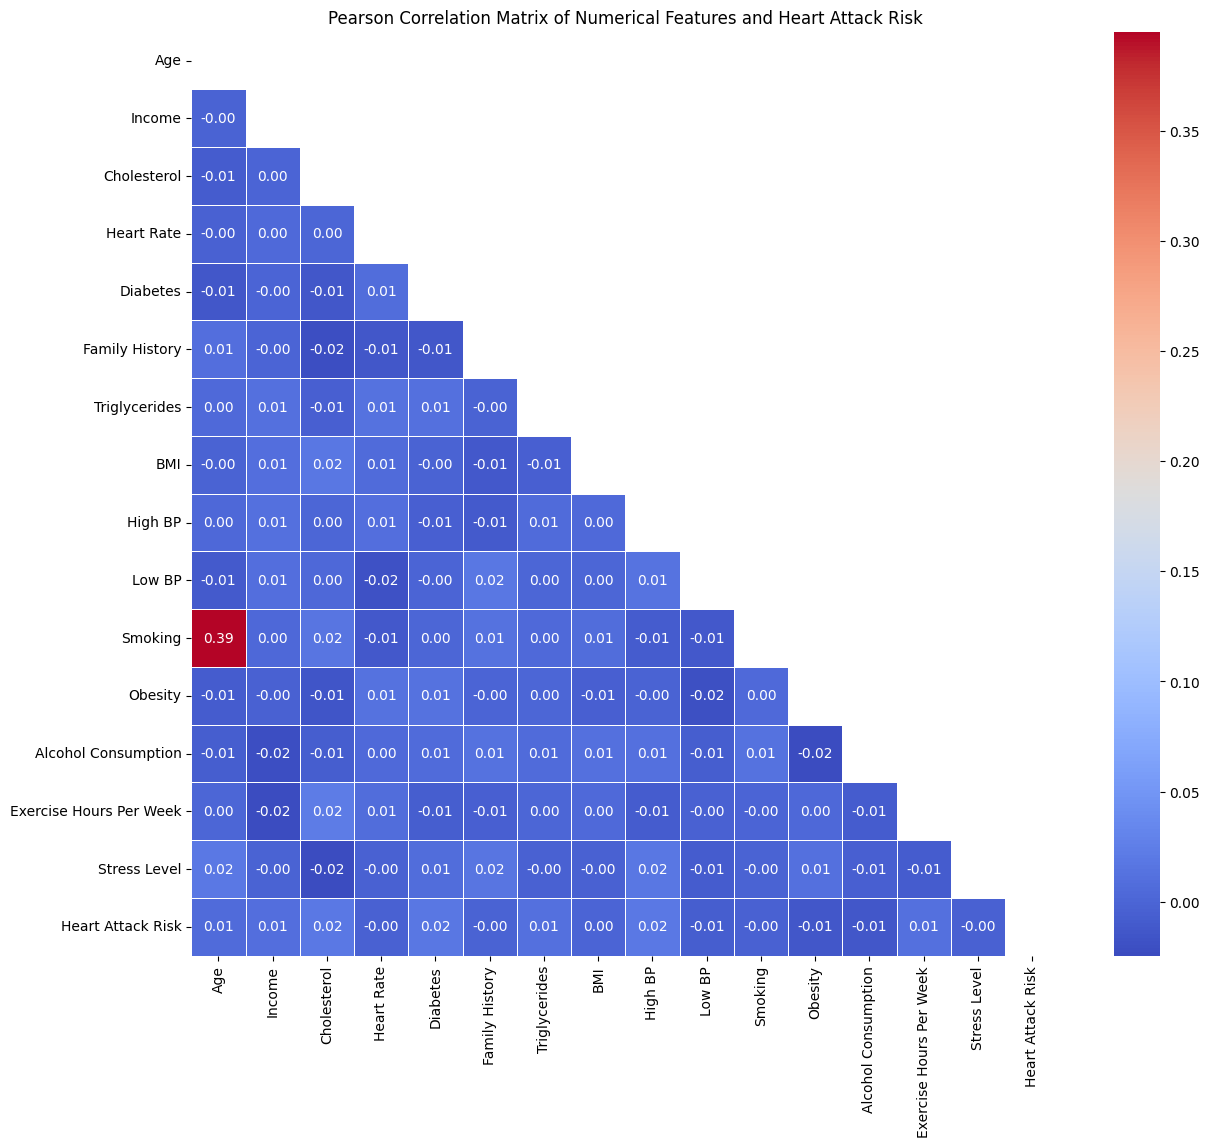

In [ ]:
merged_all_data = demographics.merge(clinical, on='Patient ID', how='left').merge(lifestyle, on='Patient ID', how='left')

numeric_cols = [
    'Age', 'Income', 'Cholesterol', 'Heart Rate', 'Diabetes',
    'Family History', 'Triglycerides', 'BMI', 'High BP', 'Low BP',
    'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
    'Stress Level', 'Heart Attack Risk'
]

# Calculate Pearson correlation matrix
pearson_corr = merged_all_data[numeric_cols].corr(method='pearson')

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=mask)
plt.title('Pearson Correlation Matrix of Numerical Features and Heart Attack Risk')
plt.show()

# Docs:
1. There is no correlation among most columns except between Smoking and Age.

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

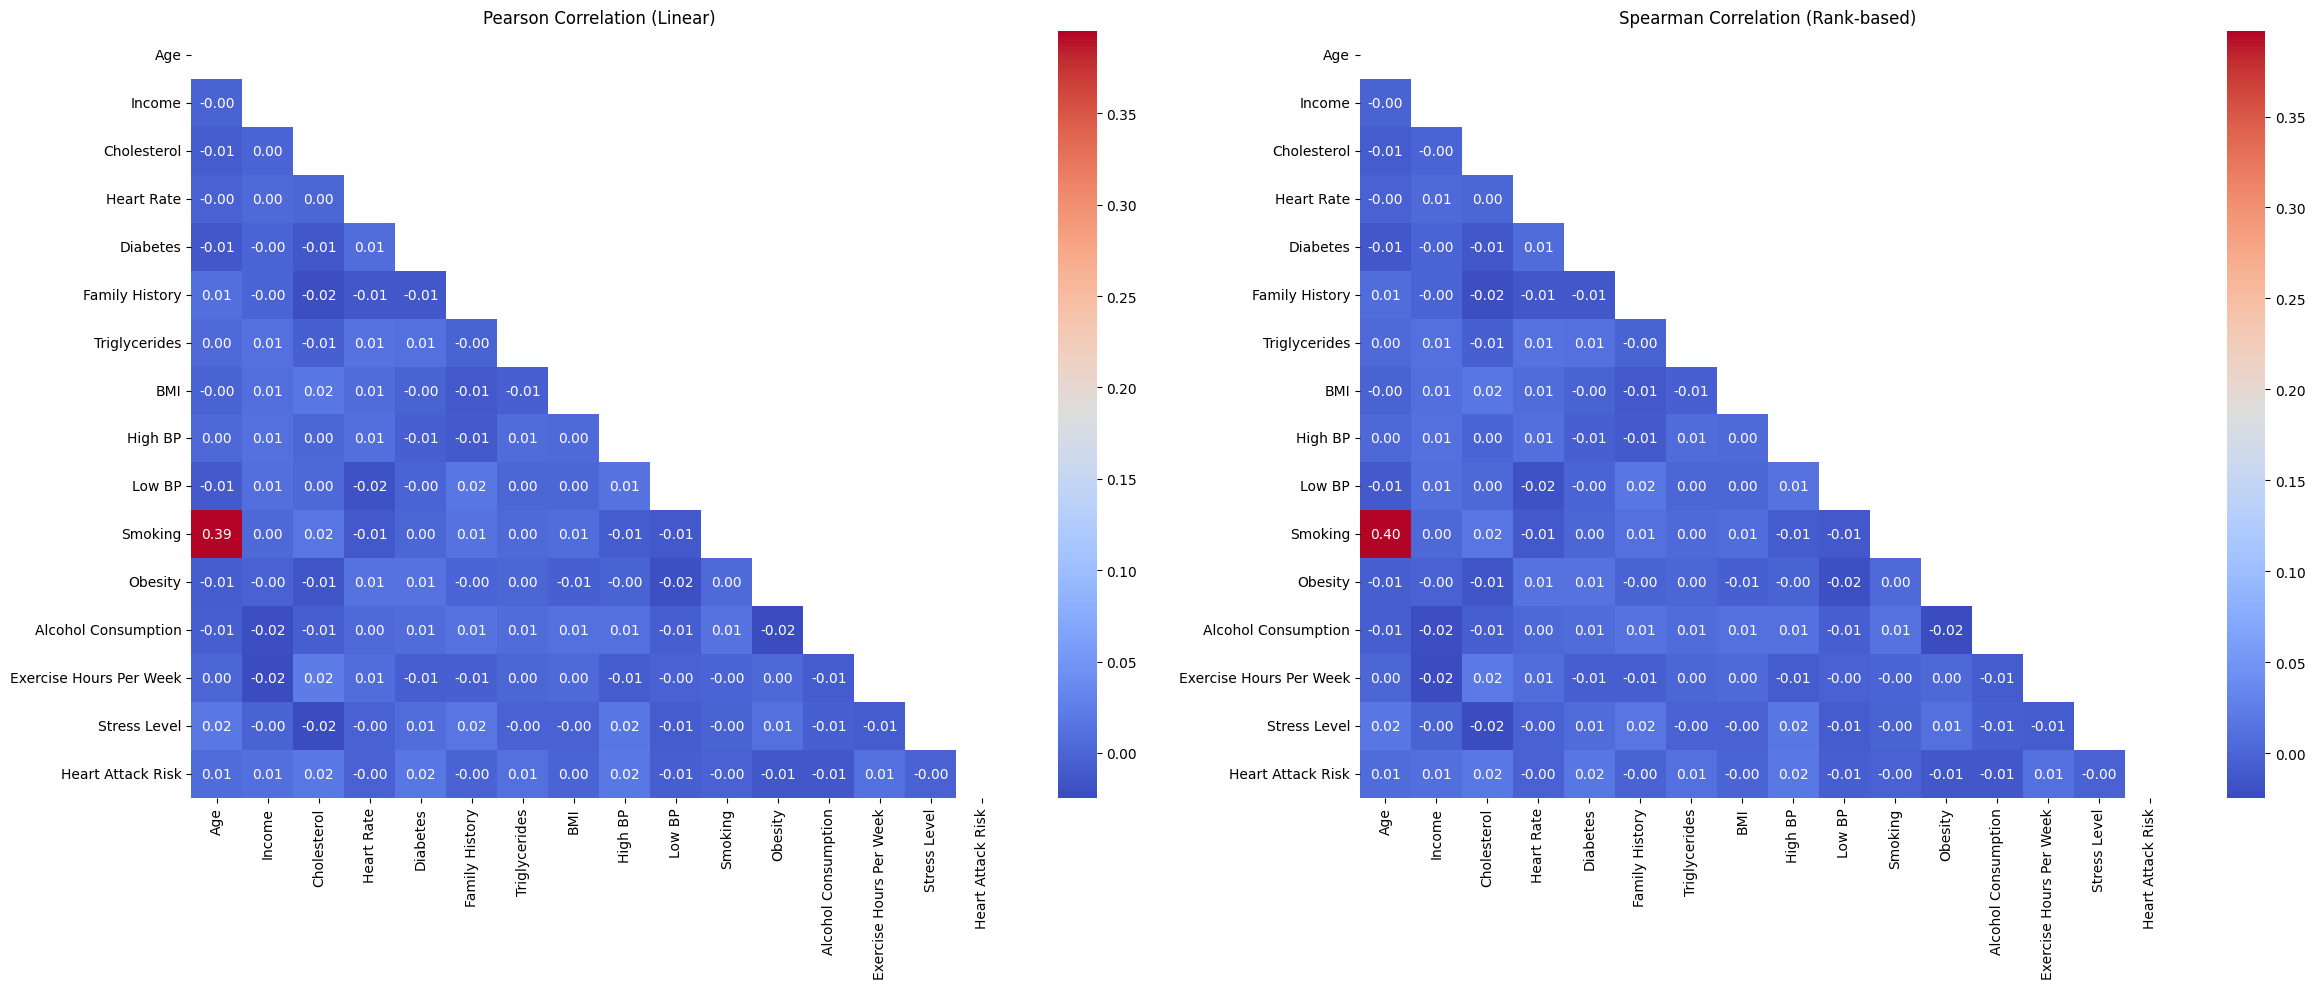

In [ ]:
spearman_corr = merged_all_data[numeric_cols].corr(method='spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot Pearson
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask, ax=ax1)
ax1.set_title('Pearson Correlation (Linear)')

# Plot Spearman
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask, ax=ax2)
ax2.set_title('Spearman Correlation (Rank-based)')

plt.tight_layout()
plt.show()

# Docs:
1. The Spearman and Pearson correlations give similar values in the context of this dataset.

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


Heart Attack Risk Counts:
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64


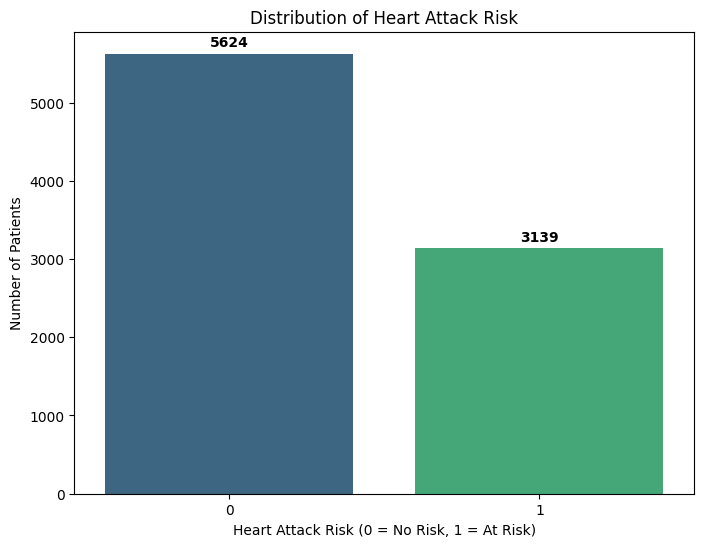

In [ ]:
# Count the occurrences of each class
risk_counts = lifestyle['Heart Attack Risk'].value_counts()
print("Heart Attack Risk Counts:")
print(risk_counts)

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=lifestyle, x='Heart Attack Risk', palette='viridis', hue='Heart Attack Risk', legend=False)
plt.title('Distribution of Heart Attack Risk')
plt.xlabel('Heart Attack Risk (0 = No Risk, 1 = At Risk)')
plt.ylabel('Number of Patients')

# Add count labels on top of bars
for i, count in enumerate(risk_counts):
    plt.text(i, count + 50, str(count), ha='center', va='bottom', fontweight='bold')

plt.show()

# Docs:
1. There are 5624 patients at no risk and 3139 at risk.

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answers:

1. Upon inspection using `.isna().sum()`, it was determined that none of the three datasets (`demographics`, `clinical`, `lifestyle`) contained missing values. Therefore, no dropping or filling was required.

2. The main issue identified was the formatting of the `Blood Pressure` column as a string (e.g., "120/80"). To make this data usable for analysis, I split it into `High BP` and `Low BP` and converted them to numeric types.

3. Age, Cholesterol, and BMI follow a normal distribution with low skewness. Categorical analysis showed that smokers represent a large portion of the 'At Risk' group. Interestingly, common clinical metrics like BMI and Cholesterol showed surprisingly low direct correlation with the target risk in this specific dataset.

4. Both Pearson and Spearman correlations were very similar and generally low (mostly < 0.1). This suggests that there are no strong linear or monotonic relationships between individual features and heart attack risk, and no significant multicollinearity issues were detected.

5. With more time, I would look for outliers using boxplots or Z-scores, especially in the Blood Pressure and Cholesterol columns. I would also explore non-linear relationships using more advanced visualizations like pair plots or joint plots segmented by the risk factor.